In [1]:
from tensorflow import keras
from keras import layers
from keras.models import Sequential
from keras.layers import Dense, Dropout
import numpy as np
from hoda_loader import load_hoda
import matplotlib.pyplot as plt

In [2]:
# Load pre-shuffled data into train and test sets
X_train, y_train, X_test, y_test = load_hoda(training_sample_size=3500, test_sample_size=400, size=32)

In [3]:
# Reshape
X_train_32 = X_train.reshape(-1, 32, 32, 1)
X_test_32 = X_test.reshape(-1, 32, 32, 1)
X_train_32.shape

(3500, 32, 32, 1)

In [4]:
import cv2
import numpy as np

In [5]:
X_train_28 = np.zeros((X_train_32.shape[0], 28, 28, 1))
for i in range(X_train_32.shape[0]):
    # Resize the sample from shape (32, 32, 1) to shape (28, 28, 1) using openCV
    resized_sample = cv2.resize(X_train_32[i], (28, 28), interpolation=cv2.INTER_AREA)
    # Assign the resized sample to the corresponding index in the new numpy array
    X_train_28[i] = resized_sample.reshape((28, 28, 1))

X_test_28 = np.zeros((X_test_32.shape[0], 28, 28, 1))
for i in range(X_test_32.shape[0]):
    # Resize the sample from shape (32, 32, 1) to shape (28, 28, 1) using openCV
    resized_sample = cv2.resize(X_test_32[i], (28, 28), interpolation=cv2.INTER_AREA)
    # Assign the resized sample to the corresponding index in the new numpy array
    X_test_28[i] = resized_sample.reshape((28, 28, 1))

In [6]:
import matplotlib.pyplot as plt

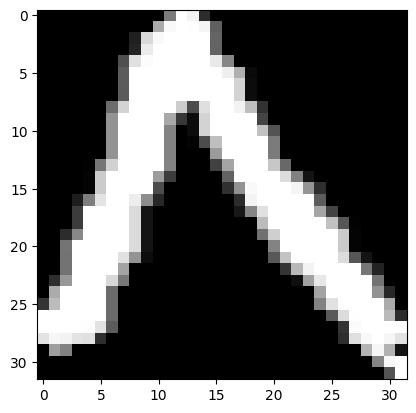

In [9]:
plt.imshow(X_test_32[0][:,:,0], cmap='gray');

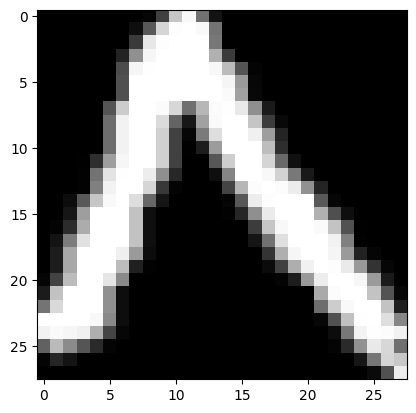

In [10]:
plt.imshow(X_test_28[0][:,:,0], cmap='gray');

In [11]:
# Pre-process input data
'''normalize our data values to the range [0, 1]'''
X_train_32 = X_train_32.astype('float32')
X_test_32 = X_test_32.astype('float32')
X_train_32 /= 255
X_test_32 /= 255

In [12]:
X_train_28 = X_train_28.astype('float32')
X_test_28 = X_test_28.astype('float32')
X_train_28 /= 255
X_test_28 /= 255

In [13]:
# Pre-process class labels
y_train = keras.utils.to_categorical(y_train)
y_test = keras.utils.to_categorical(y_test)

In [15]:
# 1st scenario

# Define model architecture
model = Sequential()
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(layers.Dense(10, activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Fit model on training data
history = model.fit(X_train_28, y_train, epochs=200, batch_size=256, validation_split=0.2)

C:\Users\aydin\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 198ms/step - accuracy: 0.2896 - loss: 2.1223 - val_accuracy: 0.5843 - val_loss: 1.6911
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - accuracy: 0.5250 - loss: 1.4355 - val_accuracy: 0.7743 - val_loss: 0.8602
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.6686 - loss: 0.9648 - val_accuracy: 0.8357 - val_loss: 0.5527
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.7536 - loss: 0.7357 - val_accuracy: 0.8600 - val_loss: 0.4425
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.7943 - loss: 0.6120 - val_accuracy: 0.8700 - val_loss: 0.3677
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.8386 - loss: 0.5056 - val_accuracy: 0.9057 - val_loss: 0.2811
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.8682 - loss: 0.4178 - val_accuracy: 0.9214 - val_loss: 0.2304
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step - accuracy: 0.8707 - loss: 0.3956 - val_accu

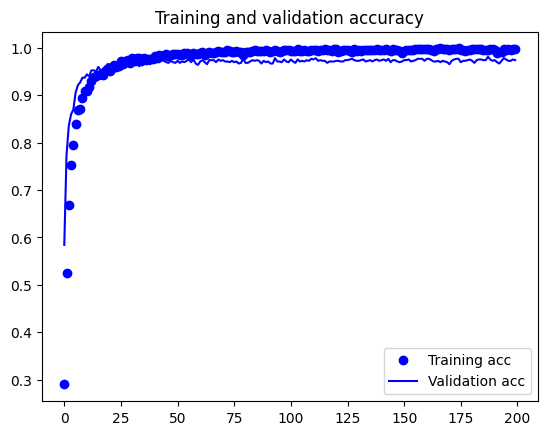

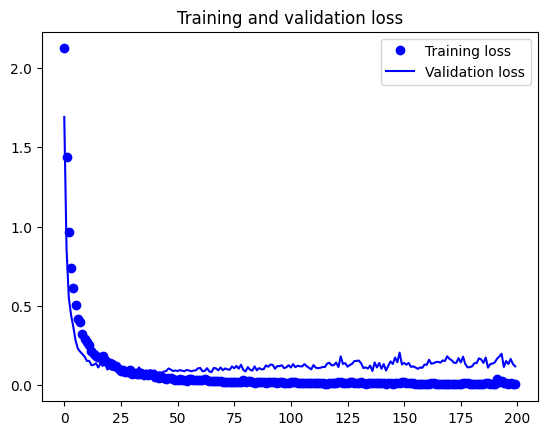

In [16]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [17]:
model.evaluate(X_test_28, y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9825 - loss: 0.1062


[0.1061716377735138, 0.9825000166893005]

In [19]:
''' Can you feed data with different dimension (such as 32x32)?'''
model.evaluate(X_test_32, y_test)

InvalidArgumentError: Graph execution error:

Detected at node StatefulPartitionedCall/sequential_1_1/dense_1/Relu defined at (most recent call last):
<stack traces unavailable>
Matrix size-incompatible: In[0]: [32,1024], In[1]: [576,64]
	 [[{{node StatefulPartitionedCall/sequential_1_1/dense_1/Relu}}]] [Op:__inference_multi_step_on_iterator_18833]

# Solution !?

In [20]:
# Define model architecture
model = Sequential()
model.add(layers.Conv2D(32, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.GlobalAveragePooling2D()) # the solution
model.add(layers.Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(layers.Dense(10, activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Fit model on training data
history = model.fit(X_train_28, y_train, epochs=80, batch_size=256, validation_split=0.2)

Epoch 1/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 194ms/step - accuracy: 0.1882 - loss: 2.2574 - val_accuracy: 0.3286 - val_loss: 2.1641
Epoch 2/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 155ms/step - accuracy: 0.3218 - loss: 2.0525 - val_accuracy: 0.5743 - val_loss: 1.7690
Epoch 3/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step - accuracy: 0.4450 - loss: 1.6626 - val_accuracy: 0.6557 - val_loss: 1.2188
Epoch 4/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.5489 - loss: 1.3125 - val_accuracy: 0.7357 - val_loss: 0.8946
Epoch 5/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.6332 - loss: 1.0608 - val_accuracy: 0.7843 - val_loss: 0.7236
Epoch 6/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.6839 - loss: 0.9034 - val_accuracy: 0.8100 - val_loss: 0.5768
Epoch 7/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - accuracy: 0.7093 - loss: 0.8157 - val_accuracy: 0.8457 - val_loss: 0.5170
Epoch 8/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.7314 - loss: 0.7270 - val_accuracy: 0.

In [21]:
# Lets evaluate it with 28x28
model.evaluate(X_test_28, y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9825 - loss: 0.0620


[0.0620262511074543, 0.9825000166893005]

In [22]:
# Now try it with different size!!
model.evaluate(X_test_32, y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9775 - loss: 0.0942


[0.09423231333494186, 0.9775000214576721]